# Study 02 — Once a penalty shootout reaches sudden death, how long should it last?

## Question

Study 01 established how often a shootout should reach sudden death under a simple equal-team model.

This study asks the natural next question:

**Once sudden death begins, how many additional rounds should we expect before the shootout is decided?**

We will start with the same baseline assumptions as Study 01:

- equal teams;
- every penalty is independent;
- every penalty has the same scoring probability;
- no player, goalkeeper, pressure, order or score-state effects.

We will again begin with a 72.5% penalty conversion probability.

## What counts as one sudden-death round?

Once sudden death begins, each team takes one penalty.

That pair of penalties is one **sudden-death round**.

A round ends the shootout only if one team scores and the other misses.

There are therefore four possible outcomes in any round:

- both score → shootout continues;
- both miss → shootout continues;
- Team A scores and Team B misses → Team A wins;
- Team A misses and Team B scores → Team B wins.

So the key quantity for this study is the probability that a sudden-death round produces **different outcomes** for the two teams.

In [1]:
import numpy as np

# Probability that a penalty is scored.
p_score = 0.725

# Create a reproducible random-number generator.
rng = np.random.default_rng(42)

# Simulate one sudden-death penalty for each team.
team_a_scores = rng.random() < p_score
team_b_scores = rng.random() < p_score

# The shootout ends if the two outcomes are different.
shootout_ends = team_a_scores != team_b_scores

team_a_scores, team_b_scores, shootout_ends

(False, True, True)

In this simulated sudden-death round, Team A missed and Team B scored.

Because the two outcomes were different, the shootout ended after this round.

If both teams had scored or both had missed, the shootout would have continued to another sudden-death round.

## A reusable sudden-death round

We now turn the logic for one sudden-death round into a function.

The function will return `True` if the round decides the shootout and `False` if both teams produce the same outcome and sudden death continues.

In [2]:
def simulate_sudden_death_round(rng, p_score):
    # Simulate one penalty for each team.
    team_a_scores = rng.random() < p_score
    team_b_scores = rng.random() < p_score

    # The shootout ends when the outcomes differ.
    return team_a_scores != team_b_scores

In [3]:
simulate_sudden_death_round(rng, p_score)

True

## Simulating a complete sudden-death sequence

A sudden-death shootout can last for one round or continue for several rounds.

We therefore repeat the same round until one team scores and the other misses.

We will count how many sudden-death rounds were needed before the shootout was decided.

In [4]:
def simulate_sudden_death_length(rng, p_score):
    # Start before the first sudden-death round.
    rounds = 0

    while True:
        # Play one sudden-death round.
        rounds += 1

        # Stop when the round decides the shootout.
        if simulate_sudden_death_round(rng, p_score):
            return rounds

In [5]:
simulate_sudden_death_length(rng, p_score)

1

This simulated sudden-death sequence lasted **1 round**.

That means the first pair of sudden-death penalties produced different outcomes: one team scored and the other missed.

If both teams had scored or both had missed, the simulation would have continued to a second round, then a third, and so on until the outcomes differed.

## Repeating sudden death many times

One simulated sequence tells us only how long that particular shootout lasted.

To understand the typical length of sudden death, we repeat the simulation many times and record the number of rounds required each time.

We will start with **100,000 simulated sudden-death sequences**.

This will let us examine both:

- the average number of sudden-death rounds;
- the full distribution, including how often the shootout ends in round 1, round 2, round 3, and so on.

In [6]:
# Number of sudden-death sequences to simulate.
n_simulations = 100_000

# Use a fresh reproducible random-number generator.
simulation_rng = np.random.default_rng(42)

# Simulate the length of each sudden-death sequence.
sudden_death_lengths = [
    simulate_sudden_death_length(simulation_rng, p_score)
    for _ in range(n_simulations)
]

# Calculate the average number of sudden-death rounds.
average_length = np.mean(sudden_death_lengths)

average_length

np.float64(2.51108)

The simulation estimates an average sudden-death length of **2.51 rounds**.

That means that, among shootouts which have already reached sudden death, the deciding miss/score mismatch occurs after roughly two and a half additional pairs of penalties on average.

The average alone does not tell us how these lengths are distributed. A mean of 2.51 could come from many different shapes.

The next step is therefore to count how often sudden death ends in round 1, round 2, round 3, and so on.

In [7]:
# Count how many simulations ended in each sudden-death round.
unique_rounds, counts = np.unique(
    sudden_death_lengths,
    return_counts=True
)

# Convert counts to proportions.
proportions = counts / n_simulations

# Display the first several rounds.
for round_number, proportion in zip(unique_rounds[:10], proportions[:10]):
    print(
        f"Round {round_number}: "
        f"{proportion:.2%}"
    )

Round 1: 39.71%
Round 2: 24.08%
Round 3: 14.56%
Round 4: 8.56%
Round 5: 5.19%
Round 6: 3.12%
Round 7: 1.88%
Round 8: 1.15%
Round 9: 0.71%
Round 10: 0.41%


## The probability that one sudden-death round ends the shootout

A sudden-death round ends when one team scores and the other misses.

There are two ways this can happen:

- Team A scores and Team B misses;
- Team A misses and Team B scores.

If the scoring probability is \(p\), then:

$$
P(\text{A scores, B misses}) = p(1-p)
$$

and:

$$
P(\text{A misses, B scores}) = (1-p)p
$$

So the probability that a single sudden-death round ends the shootout is:

$$
P(\text{round ends shootout}) = 2p(1-p)
$$

At our 72.5% baseline, we can calculate this exactly.

In [8]:
# Exact probability that one sudden-death round decides the shootout.
round_end_probability = 2 * p_score * (1 - p_score)

print(f"Probability round ends shootout: {round_end_probability:.3%}")

Probability round ends shootout: 39.875%


The exact probability that a single sudden-death round decides the shootout is **39.875%**.

Our simulation found **39.71%** of sudden-death sequences ending in round 1, which is very close.

So, once sudden death begins, there is roughly a **40% chance it ends immediately**.

If the round does not end the shootout, both teams must have produced the same outcome — either both scored or both missed — and the process simply repeats under the same assumptions.

In [9]:
# Exact expected number of sudden-death rounds.
exact_average_length = 1 / round_end_probability

print(f"Exact expected length: {exact_average_length:.5f} rounds")

Exact expected length: 2.50784 rounds


The exact expected sudden-death length is **2.50784 rounds**.

Our simulation estimated **2.51108 rounds**, so the two methods agree very closely.

This gives us another validation of the simulation.

The reason we can calculate the expectation so simply is that every sudden-death round is the same experiment again:

- there is a 39.875% chance the shootout ends;
- otherwise it continues to another round with exactly the same probabilities.

This is a **geometric distribution**.

## Distribution of sudden-death length

The average tells us that sudden death lasts about 2.5 rounds, but the distribution is more informative.

Because each round has the same probability of ending the shootout, the exact probability that the shootout ends in round \(k\) is:

$$
P(\text{ends in round } k)
=
(1-q)^{k-1}q
$$

where \(q\) is the probability that any one round decides the shootout.

We can compare this exact distribution with the results of our 100,000 simulated shootouts.

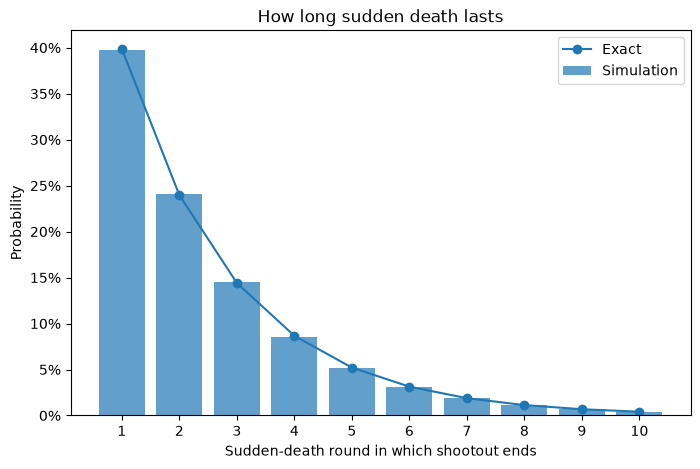

In [10]:
import matplotlib.pyplot as plt

# Sudden-death rounds to display.
rounds_to_plot = np.arange(1, 11)

# Exact geometric probability of ending in each round.
exact_round_probabilities = (
    (1 - round_end_probability) ** (rounds_to_plot - 1)
    * round_end_probability
)

# Simulated proportions for the same rounds.
simulated_round_probabilities = np.array([
    np.mean(np.array(sudden_death_lengths) == round_number)
    for round_number in rounds_to_plot
])

# Plot simulated and exact probabilities.
plt.figure(figsize=(8, 5))

plt.bar(
    rounds_to_plot,
    simulated_round_probabilities,
    label="Simulation",
    alpha=0.7
)

plt.plot(
    rounds_to_plot,
    exact_round_probabilities,
    marker="o",
    label="Exact"
)

plt.title("How long sudden death lasts")
plt.xlabel("Sudden-death round in which shootout ends")
plt.ylabel("Probability")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.xticks(rounds_to_plot)
plt.legend()
plt.show()

### Interpreting the distribution

Most sudden-death shootouts are decided quickly.

At a 72.5% scoring probability:

- about **39.9%** end in the first sudden-death round;
- about **24.0%** end in round 2;
- about **14.4%** end in round 3;
- fewer than 10% survive to be decided in any individual later round.

The probability falls geometrically because every round is the same independent experiment again.

The simulation closely follows the exact distribution, giving us confidence that the sudden-death model is behaving as intended.

## How does conversion probability affect sudden-death length?

The probability that one sudden-death round ends the shootout is:

$$
q = 2p(1-p)
$$

and the expected number of sudden-death rounds is:

$$
E(\text{rounds}) = \frac{1}{2p(1-p)}
$$

We can therefore calculate the expected sudden-death length directly for different penalty conversion probabilities.

As in Study 01, we will examine values from 50% to 95% in five-percentage-point steps.

In [11]:
# Penalty conversion probabilities to examine.
conversion_probabilities = np.arange(0.50, 0.951, 0.05)

# Calculate the exact expected sudden-death length at each value.
expected_lengths = [
    1 / (2 * p * (1 - p))
    for p in conversion_probabilities
]

# Display the results.
for p, expected_length in zip(
    conversion_probabilities,
    expected_lengths
):
    print(
        f"{p:.0%} conversion: "
        f"{expected_length:.3f} sudden-death rounds"
    )

50% conversion: 2.000 sudden-death rounds
55% conversion: 2.020 sudden-death rounds
60% conversion: 2.083 sudden-death rounds
65% conversion: 2.198 sudden-death rounds
70% conversion: 2.381 sudden-death rounds
75% conversion: 2.667 sudden-death rounds
80% conversion: 3.125 sudden-death rounds
85% conversion: 3.922 sudden-death rounds
90% conversion: 5.556 sudden-death rounds
95% conversion: 10.526 sudden-death rounds


### Better penalty taking makes sudden death last longer

Once the conversion probability is above 50%, higher scoring rates make sudden death progressively longer.

At a 50% conversion probability, the expected sudden-death length is exactly **2 rounds**.

By comparison:

- 70% conversion → 2.381 rounds;
- 80% conversion → 3.125 rounds;
- 90% conversion → 5.556 rounds;
- 95% conversion → 10.526 rounds.

The reason is the same mechanism we saw in Study 01.

Sudden death only ends when the two teams produce different outcomes. As scoring becomes very likely, both teams increasingly score together, so the shootout survives to another round.

At very high conversion probabilities, this effect becomes extreme.

## Visualising the effect of conversion probability

The table shows that expected sudden-death length rises slowly at first and then much more sharply at very high conversion rates.

A graph makes that non-linear relationship easier to see.

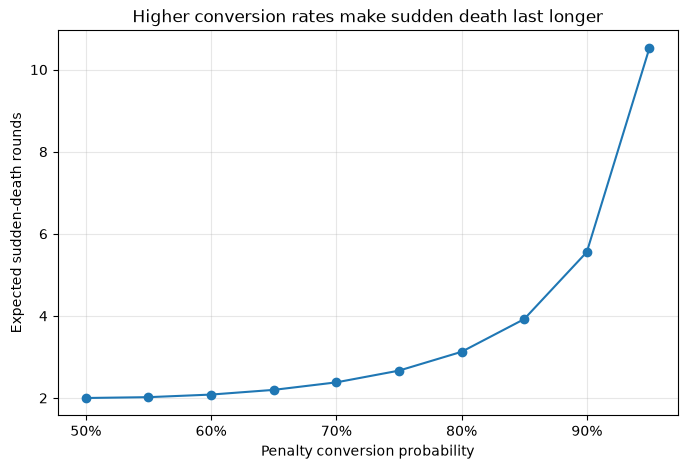

In [12]:
# Plot conversion probability against expected sudden-death length.
plt.figure(figsize=(8, 5))

plt.plot(
    conversion_probabilities,
    expected_lengths,
    marker="o"
)

plt.title("Higher conversion rates make sudden death last longer")
plt.xlabel("Penalty conversion probability")
plt.ylabel("Expected sudden-death rounds")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.grid(alpha=0.3)
plt.show()

### Interpreting the curve

The expected length of sudden death rises slowly at ordinary conversion rates, then accelerates sharply as penalties become very likely to be scored.

At around 70%–80% conversion, sudden death typically lasts only a few rounds.

Above 90%, however, the expected length rises quickly because both teams are increasingly likely to score together and therefore cancel each other out.

This is the same basic mechanism we saw in Study 01: when both teams are highly likely to produce the same outcome, shootouts become harder to separate.

## Study conclusion

Once a penalty shootout reaches sudden death, its expected length depends directly on the probability that a single round produces different outcomes for the two teams.

At the 72.5% baseline:

- a sudden-death round ends the shootout with probability **39.875%**;
- the expected sudden-death length is **2.508 rounds**;
- about **39.9%** of sudden-death shootouts end immediately;
- about **24.0%** end in round 2;
- the remaining probability forms a steadily shrinking tail.

The simulation and exact geometric calculation agree closely.

Changing the penalty conversion probability produces the main result of this study:

**better penalty conversion makes sudden death last longer.**

Above 50% conversion, both teams become increasingly likely to produce the same outcome in each round. Most commonly, both score. Because a sudden-death round only decides the shootout when one team scores and the other misses, matching outcomes keep the shootout alive.

This effect becomes increasingly strong at very high conversion rates:

- 70% conversion → 2.381 expected rounds;
- 80% → 3.125 rounds;
- 90% → 5.556 rounds;
- 95% → 10.526 rounds.

### Connection with Study 01

Study 01 showed that higher conversion probabilities make a shootout **more likely to reach sudden death**.

Study 02 shows that, once sudden death begins, higher conversion probabilities also make it **last longer**.

Both results come from the same underlying mechanism: as scoring becomes more likely, the two teams increasingly produce matching outcomes.

### Scope decision

The question has been answered under the baseline equal-team model.

We stop here rather than adding unequal teams, individual kickers, pressure effects or real-world data. Those would change the sporting question and should be investigated separately if there is a reason to do so.